# Phishing Website Detection using Machine Learning
Phishing Website Detection Using Machine Learning
Author: Monika Thapa (Student ID: 24263113)
Course: COMP971 - Master's Dissertation
Supervisor: Professor Minh Nguyen
Institution: Auckland University of Technology

Objective: This notebook trains and evaluates three machine learning classifiers (Logistic Regression, Decision Tree, and Random Forest) on the UCI Phishing Websites benchmark dataset (30 features). The best-performing model (Random Forest) is then analysed using SHAP and LIME for explainability.




In [2]:
# Importing Libraries:
#These libraries are used for handling data, visualization, and building machine learning models
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

# 2. Loading the Dataset
The UCI Phishing Websites Dataset (Mohammad et al., 2014) is provided in ARFF format. It contains 11,055 website samples with 30 input features and 1 target label (Result), where 1 = Legitimate and -1 = Phishing. This dataset serves as the benchmark for training and evaluation.

In [4]:
# we are using scipy.io.arff to read ARFF datasets 
from scipy.io import arff 
# Loading the phishing dataset from ARFF file
data, meta = arff.loadarff("/Users/monika/Downloads/phishing+websites/Training Dataset.arff") # the path where my dataset is stored in my system
phishing_df = pd.DataFrame(data)

In [5]:
phishing_df.head()
#Preview the dataset by displaying the first five default rows

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,b'-1',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'-1',b'1',...,b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',b'1',b'-1',b'-1'
1,b'1',b'1',b'1',b'1',b'1',b'-1',b'0',b'1',b'-1',b'1',...,b'1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'-1'
2,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',...,b'1',b'1',b'1',b'-1',b'1',b'-1',b'1',b'0',b'-1',b'-1'
3,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'1',b'1',...,b'1',b'1',b'-1',b'-1',b'1',b'-1',b'1',b'-1',b'1',b'-1'
4,b'1',b'0',b'-1',b'1',b'1',b'-1',b'1',b'1',b'-1',b'1',...,b'-1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'1'


In [6]:
phishing_df.shape
# Checking the shape of the dataset (rows = samples, columns = features)

(11055, 31)

In [7]:
# In ARFF files, values are loaded as byte strings (e.g., b'-1')
# So we convert them into integers for proper machine learning processing
for col in phishing_df.columns:
    if phishing_df[col].dtype == object:
        phishing_df[col] = phishing_df[col].str.decode("utf-8").astype(int)

In [8]:
phishing_df.head()
# it has now been converted into interger/numbers

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


# 3. Exploratory Data Analysis (EDA)
Before building models, we examine the dataset to understand its structure, check for missing values, and identify any issues that need to be addressed.

In [10]:
phishing_df.columns
# Displaying all column names including features and targets
# The dataset includes 30 features used for classification and 1 target label (Result)

Index(['having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
       'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length',
       'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor',
       'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL',
       'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe',
       'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank',
       'Google_Index', 'Links_pointing_to_page', 'Statistical_report',
       'Result'],
      dtype='object')

In [11]:
# Checking datatypes for each column:
phishing_df.dtypes
# Ensuring all features are numeric for machine learning models

having_IP_Address              int64
URL_Length                     int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        int64
port                           int64
HTTPS_token                    int64
Request_URL                    int64
URL_of_Anchor                  int64
Links_in_tags                  int64
SFH                            int64
Submitting_to_email            int64
Abnormal_URL                   int64
Redirect                       int64
on_mouseover                   int64
RightClick                     int64
popUpWidnow                    int64
Iframe                         int64
age_of_domain                  int64
DNSRecord                      int64
web_traffic                    int64
Page_Rank                      int64
G

In [12]:
phishing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  i

In [13]:
phishing_df['Result'].value_counts()
#Checking class distribution
# 1 = Legitimate website
# -1 = Phishing website

Result
 1    6157
-1    4898
Name: count, dtype: int64

In [14]:
# Data Preprocessing
phishing_df.isnull().sum()
# No missing values found in the dataset

having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistical_report             0
Result    

In [15]:
phishing_df.isnull().any()
# The output shows False for all columns, indicating that there are no missing values in the dataset

having_IP_Address              False
URL_Length                     False
Shortining_Service             False
having_At_Symbol               False
double_slash_redirecting       False
Prefix_Suffix                  False
having_Sub_Domain              False
SSLfinal_State                 False
Domain_registeration_length    False
Favicon                        False
port                           False
HTTPS_token                    False
Request_URL                    False
URL_of_Anchor                  False
Links_in_tags                  False
SFH                            False
Submitting_to_email            False
Abnormal_URL                   False
Redirect                       False
on_mouseover                   False
RightClick                     False
popUpWidnow                    False
Iframe                         False
age_of_domain                  False
DNSRecord                      False
web_traffic                    False
Page_Rank                      False
G

In [16]:
# Getting a statistical summary of the dataset
phishing_df.describe()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [17]:
# Checking class distribution of the dataset
# The 'Result' column represents the class label:
#  1  = Legitimate website
# -1  = Phishing website

print("Class Distribution:")
# value_counts() shows the number of samples in each class
print(phishing_df['Result'].value_counts())

print("\nPercentage Distribution:")
# normalize=True gives proportions, multiplied by 100 for percentage
print(phishing_df['Result'].value_counts(normalize=True) * 100)

Class Distribution:
Result
 1    6157
-1    4898
Name: count, dtype: int64

Percentage Distribution:
Result
 1    55.694256
-1    44.305744
Name: proportion, dtype: float64


In [18]:
# Checking for duplicate rows in the dataset
phishing_df.duplicated().sum()

np.int64(5206)

In [19]:
## Removing duplicate rows
phishing_df = phishing_df.drop_duplicates().reset_index(drop=True)

In [20]:
# Checking if duplicates have been removed
phishing_df.duplicated().sum()

np.int64(0)

In [21]:
phishing_df['Result'].value_counts()

Result
-1    3019
 1    2830
Name: count, dtype: int64

In [22]:
phishing_df.value_counts()

having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  Domain_registeration_length  Favicon  port  HTTPS_token  Request_URL  URL_of_Anchor  Links_in_tags  SFH  Submitting_to_email  Abnormal_URL  Redirect  on_mouseover  RightClick  popUpWidnow  Iframe  age_of_domain  DNSRecord  web_traffic  Page_Rank  Google_Index  Links_pointing_to_page  Statistical_report  Result
-1                 -1          -1                  -1                -1                        -1             -1                 -1              -1                           -1       -1    -1           -1            0              1             -1   -1                   -1            1         -1            1            1           -1       1             -1          1           -1         1             1                        1                  -1        1
 1                 -1           1                   1                 1          

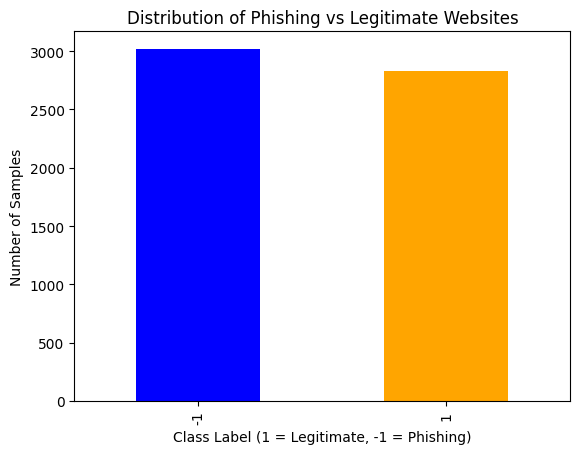

In [23]:
# Visualizing class distribution
phishing_df['Result'].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title("Distribution of Phishing vs Legitimate Websites")
plt.xlabel("Class Label (1 = Legitimate, -1 = Phishing)")
plt.ylabel("Number of Samples")
plt.show()

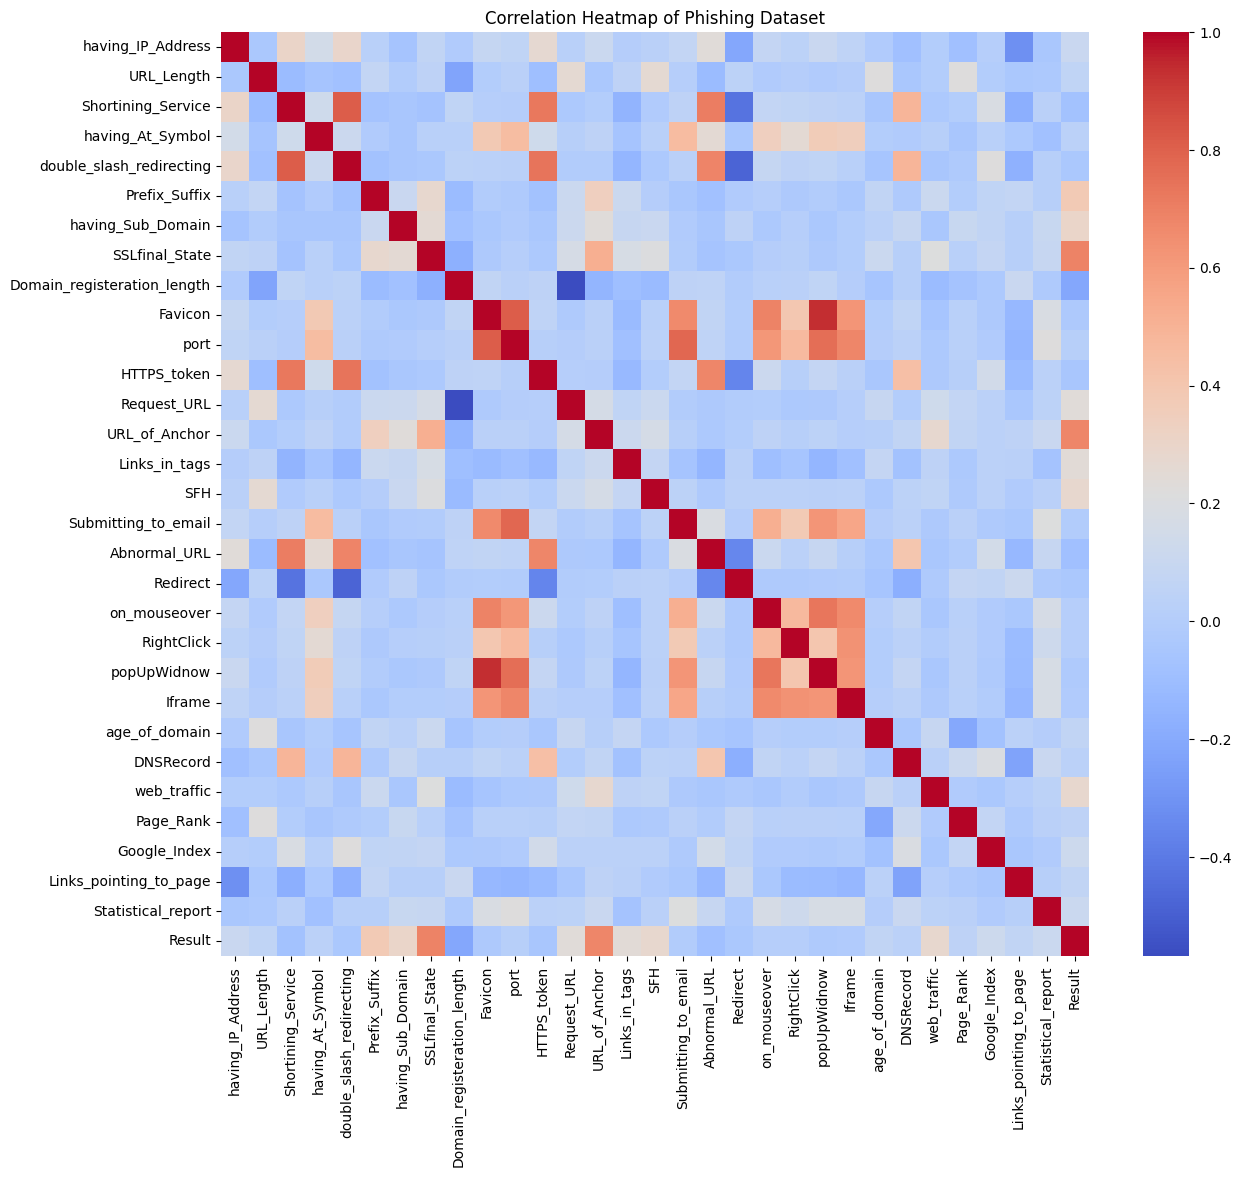

In [24]:
# Correlation Heatmap of Phishing Dataset
# A correlation heatmap helps visualize relationships between features.
# Values close to 1 indicate strong positive correlation,
# values close to -1 indicate strong negative correlation,
# and values near 0 indicate little or no relationship.
plt.figure(figsize=(14, 12))
sns.heatmap(phishing_df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Phishing Dataset")
plt.show()

In [25]:
# Correlation of each feature with the target variable (Result)
target_corr = phishing_df.corr()["Result"].sort_values(ascending=False)
print(target_corr)

Result                         1.000000
SSLfinal_State                 0.693228
URL_of_Anchor                  0.679125
Prefix_Suffix                  0.381134
having_Sub_Domain              0.296214
web_traffic                    0.281709
SFH                            0.281131
Links_in_tags                  0.243864
Request_URL                    0.237778
Google_Index                   0.118217
Statistical_report             0.108486
having_IP_Address              0.104952
Links_pointing_to_page         0.068463
age_of_domain                  0.062800
URL_Length                     0.058228
Page_Rank                      0.048140
having_At_Symbol               0.034757
DNSRecord                      0.033204
port                           0.014201
on_mouseover                   0.012790
RightClick                     0.009286
Submitting_to_email           -0.008014
Iframe                        -0.011756
popUpWidnow                   -0.022455
Favicon                       -0.025457


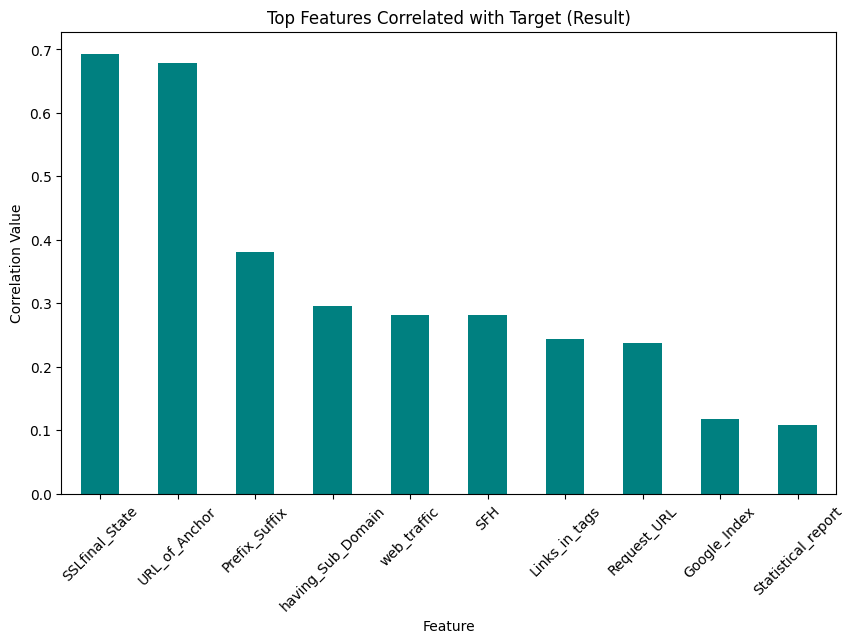

In [26]:
# Top correlations with target variable
target_corr = phishing_df.corr()["Result"].sort_values(ascending=False)
plt.figure(figsize=(10,6))
target_corr[1:11].plot(kind="bar", color="teal")
plt.title("Top Features Correlated with Target (Result)")
plt.xlabel("Feature")
plt.ylabel("Correlation Value")
plt.xticks(rotation=45)
plt.show()

# Baseline Model: Logistic Regression

In [28]:
# Splitting the dataset into training and testing sets: 
from sklearn.model_selection import train_test_split
# Separate input features (X) and target variable (y)
X = phishing_df.drop('Result', axis=1)   # All phishing indicators (features)
y = phishing_df['Result']                # Target variable: 1 = legitimate, -1 = phishing
# Split the dataset into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
# Display dataset sizes
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (4679, 30)
Testing set size: (1170, 30)


In [29]:
from sklearn.preprocessing import StandardScaler
# Scaling features using StandardScaler
scaler = StandardScaler()
# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

In [30]:
# Convert scaled arrays back to DataFrames to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

In [31]:
# Training Logistic Regression Model
from sklearn.linear_model import LogisticRegression
# Creating Logistic Regression model
logit_model = LogisticRegression(max_iter=2000, random_state=42)
# Training the model on scaled training data
logit_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [32]:
# Making predictions with Logistic Regression
# Predicting class labels
y_pred_lr = logit_model.predict(X_test_scaled)
# Predicting probabilities for ROC-AUC calculation
y_prob_lr = logit_model.predict_proba(X_test_scaled)[:, 1]

In [33]:
# Evaluating Logistic Regression Model
# We evaluate the model using accuracy, precision, recall, F1-score, and confusion matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Calculate accuracy
logit_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", logit_accuracy)
# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
# Print confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr, labels=[-1, 1]))

Logistic Regression Accuracy: 0.9128205128205128

Classification Report:
              precision    recall  f1-score   support

          -1       0.93      0.90      0.91       604
           1       0.90      0.92      0.91       566

    accuracy                           0.91      1170
   macro avg       0.91      0.91      0.91      1170
weighted avg       0.91      0.91      0.91      1170


Confusion Matrix:
[[546  58]
 [ 44 522]]


In [34]:
# Calculating ROC-AUC Score
# ROC-AUC measures how well the model distinguishes between phishing and legitimate websites
from sklearn.metrics import roc_auc_score
logit_auc = roc_auc_score(y_test, y_prob_lr)
print("Logistic Regression ROC-AUC Score:", logit_auc)

Logistic Regression ROC-AUC Score: 0.9738024477570028


<Figure size 700x700 with 0 Axes>

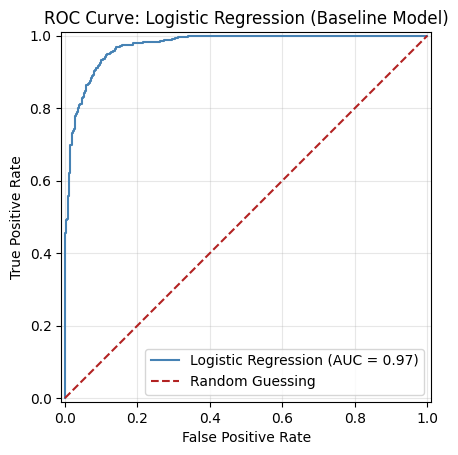

In [35]:
from sklearn.metrics import RocCurveDisplay
# Plotting ROC Curve
plt.figure(figsize=(7, 7))
RocCurveDisplay.from_estimator(logit_model,X_test_scaled,y_test,name="Logistic Regression",color='steelblue')
# Adding baseline (random guess) line
plt.plot([0, 1], [0, 1], linestyle='--', color='firebrick', label='Random Guessing')
plt.title("ROC Curve: Logistic Regression (Baseline Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

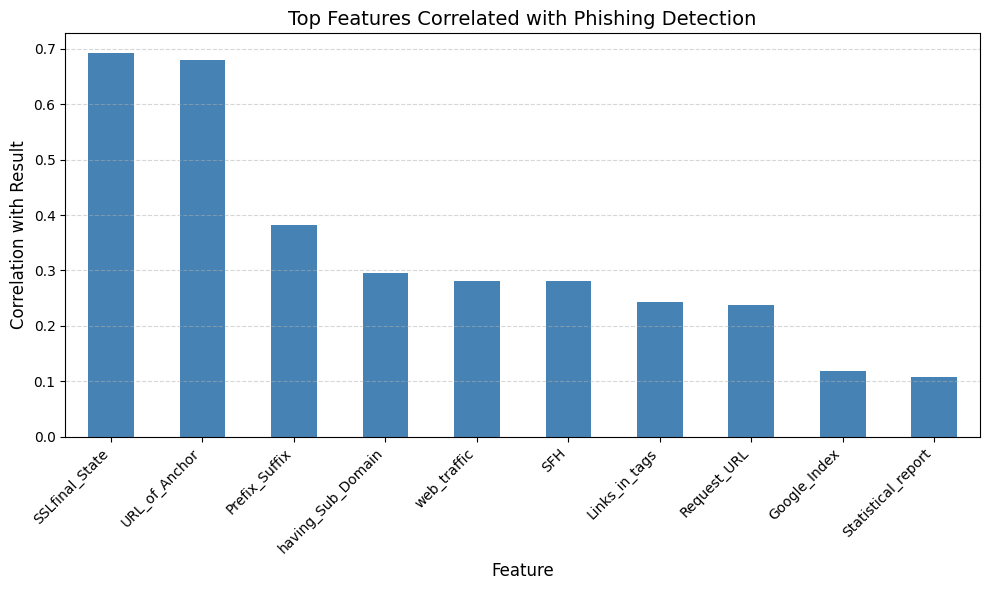

In [36]:
# Vizualizing the top 10 features
# This bar chart shows the top 10 features that are most positively correlated with the target variable Result
plt.figure(figsize=(10,6))
target_corr[1:11].plot(kind="bar", color="steelblue")
plt.title("Top Features Correlated with Phishing Detection", fontsize=14)
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Correlation with Result", fontsize=12)
plt.xticks(rotation=45, ha="right")   # improves readability
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout() 
plt.show()

# Model 2 - Decision Tree

# Decision Tree is the second classifier, trained on unscaled data as tree-based models are not sensitive to feature magnitudes.

In [39]:
from sklearn.tree import DecisionTreeClassifier
# Creating Decision Tree model
dtree = DecisionTreeClassifier(random_state=42)
# Training the model on training data
dtree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [40]:
# Predicting class labels
y_pred_dt = dtree.predict(X_test)
# Predicting probabilities for ROC-AUC
y_prob_dt = dtree.predict_proba(X_test)[:, 1]
# No scaling is needed because Decision Trees split data based on thresholds,not on distances or feature magnitudes

In [41]:
# Evaluating Decision Tree model performance Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt, labels=[-1, 1]))

Decision Tree Accuracy: 0.917094017094017

Classification Report:
              precision    recall  f1-score   support

          -1       0.92      0.92      0.92       604
           1       0.92      0.91      0.91       566

    accuracy                           0.92      1170
   macro avg       0.92      0.92      0.92      1170
weighted avg       0.92      0.92      0.92      1170


Confusion Matrix:
[[558  46]
 [ 51 515]]


In [42]:
from sklearn.metrics import roc_auc_score
# Calculate AUC score
dt_auc = roc_auc_score(y_test, y_prob_dt)
print("Decision Tree ROC-AUC Score:", dt_auc)

Decision Tree ROC-AUC Score: 0.9219090047504271


<Figure size 700x700 with 0 Axes>

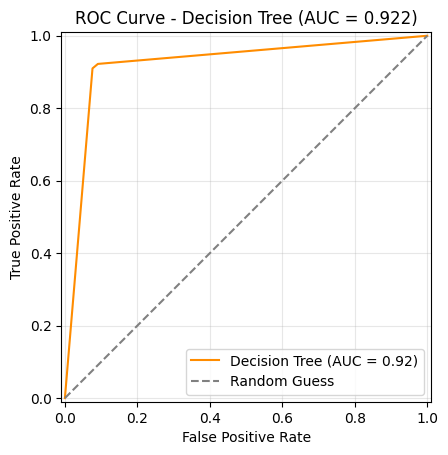

In [43]:
# Plotting ROC Curve for Decision Tree
plt.figure(figsize=(7, 7))
RocCurveDisplay.from_estimator(dtree,X_test, y_test,name="Decision Tree",color="darkorange")
# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--', color="gray", label="Random Guess")
plt.title(f"ROC Curve - Decision Tree (AUC = {dt_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [44]:
# To check if my decision tree is overfitting or not:
# Training accuracy
train_accuracy = dtree.score(X_train, y_train)
# Testing accuracy
test_accuracy = dtree.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9908100021372088
Testing Accuracy: 0.917094017094017


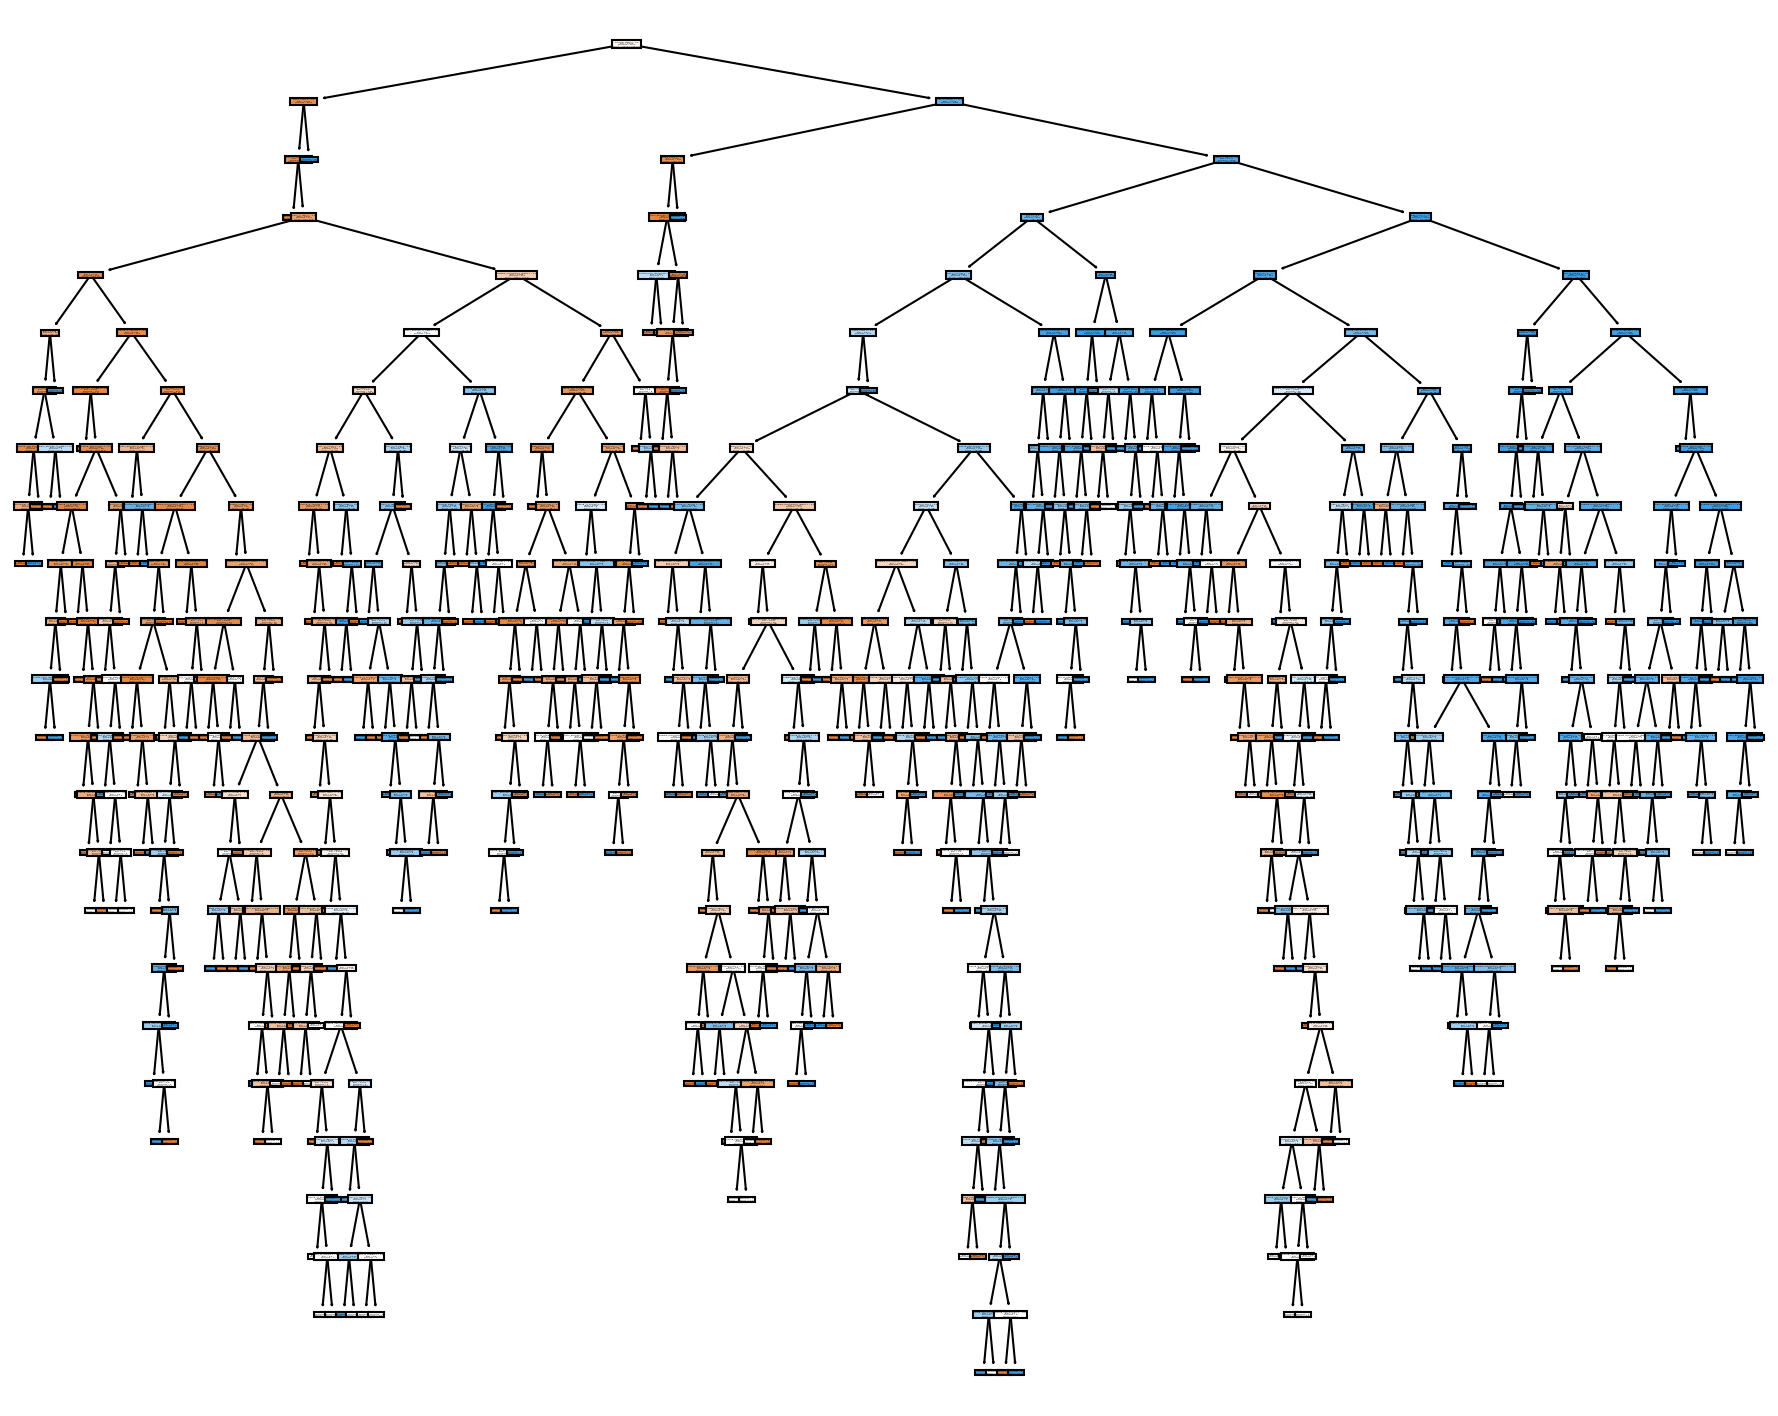

In [45]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,12), dpi=150)
plot_tree(dtree, filled=True, feature_names=X_train.columns)
plt.show()

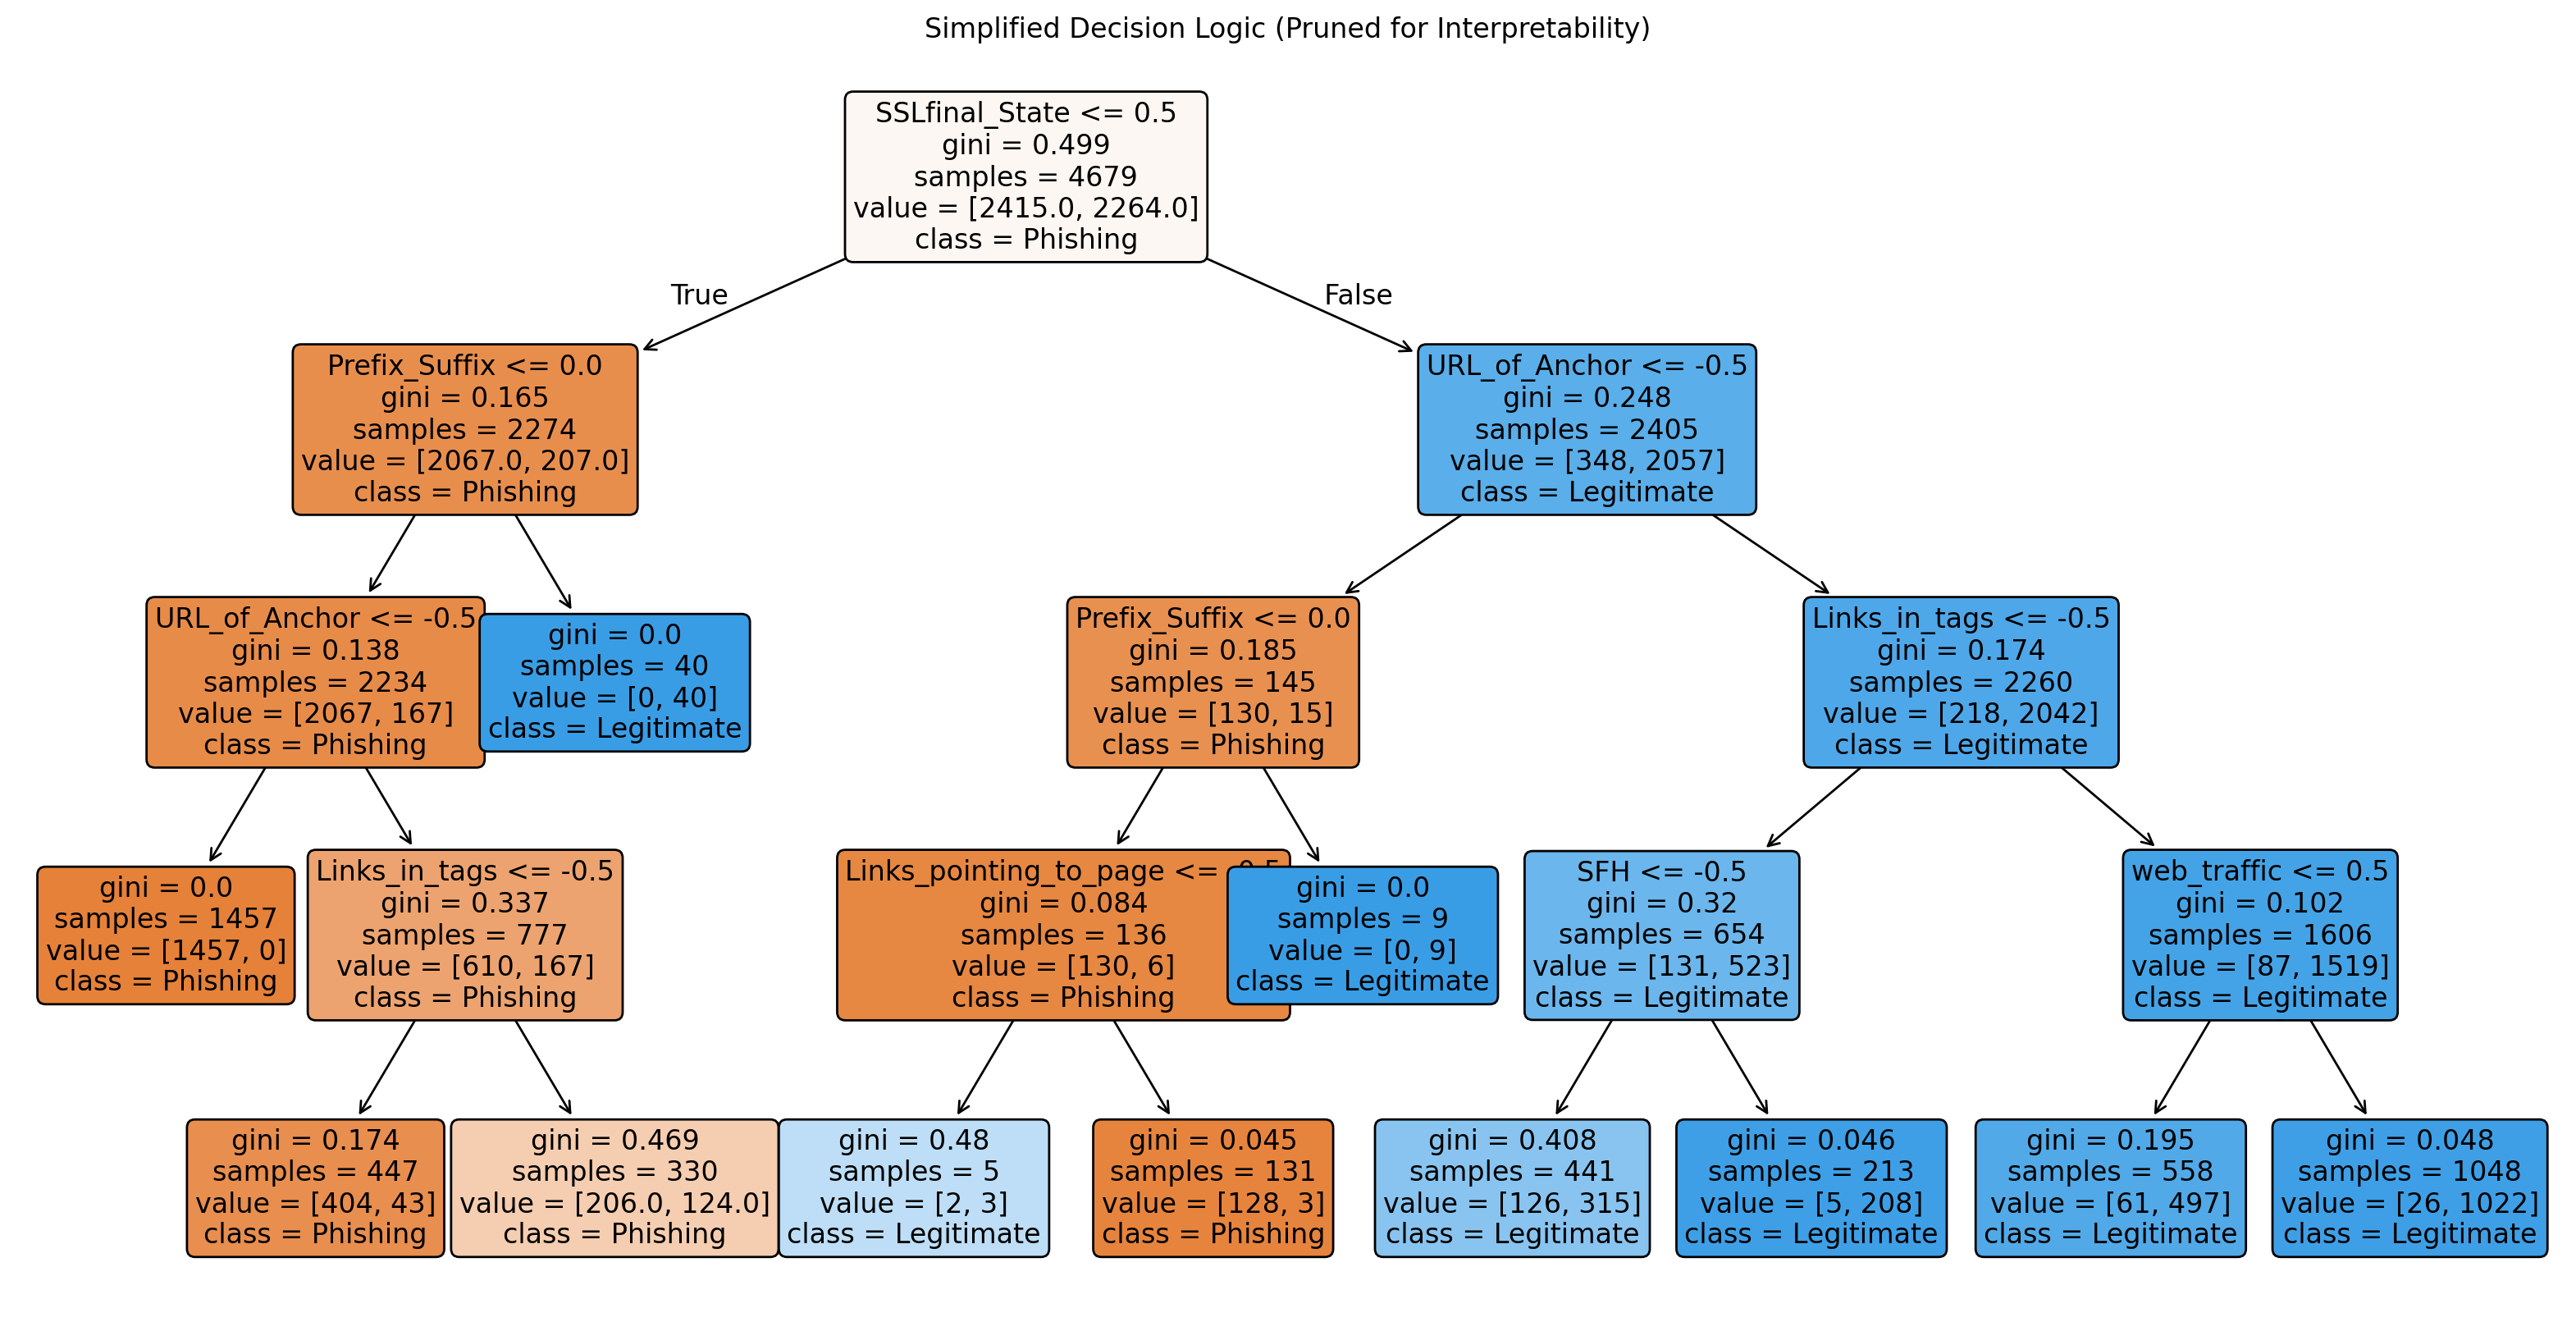

Pruned Test Accuracy: 0.9043


In [46]:
# Train a simpler tree (limiting depth to 4)
dtree_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree_pruned.fit(X_train, y_train)
# Visualizing the simplified logic
plt.figure(figsize=(20,10), dpi=200)
plot_tree(dtree_pruned, filled=True, feature_names=X_train.columns, class_names=['Phishing', 'Legitimate'], rounded=True, fontsize=12)
plt.title("Simplified Decision Logic (Pruned for Interpretability)")
plt.show()
# Checking the new accuracy
print(f"Pruned Test Accuracy: {dtree_pruned.score(X_test, y_test):.4f}")

# Model 3- Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
# creating Random Forest Model: 
# n_estimators=100 means we are building 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [50]:
# Training the model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [51]:
# Making Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

Random Forest Accuracy: 0.9436

Classification Report:
              precision    recall  f1-score   support

    Phishing       0.95      0.94      0.95       604
  Legitimate       0.94      0.95      0.94       566

    accuracy                           0.94      1170
   macro avg       0.94      0.94      0.94      1170
weighted avg       0.94      0.94      0.94      1170



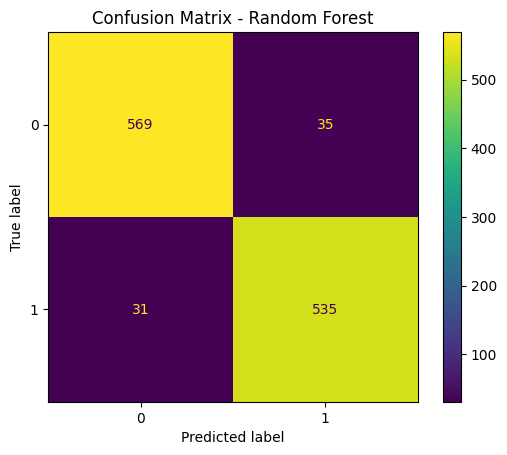

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
# Classification report
print("\nClassification Report:")
print(classification_report(y_test,y_pred_rf,labels=[-1, 1],target_names=["Phishing", "Legitimate"]))
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred_rf, labels=[-1, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [53]:
# Calculating ROC-AUC score for the Random Forest model
rf_auc = roc_auc_score(y_test, y_prob_rf)
print("Random Forest ROC-AUC Score:", rf_auc)

Random Forest ROC-AUC Score: 0.9881093066248567


<Figure size 700x700 with 0 Axes>

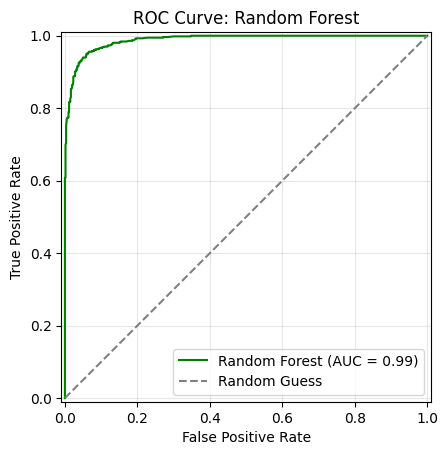

In [54]:
# Plotting ROC Curve for Random Forest
plt.figure(figsize=(7, 7))
RocCurveDisplay.from_estimator(rf_model,X_test,y_test,name="Random Forest",color="green")
# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--', color="gray", label="Random Guess")
plt.title("ROC Curve: Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Comparing all 3 Models:

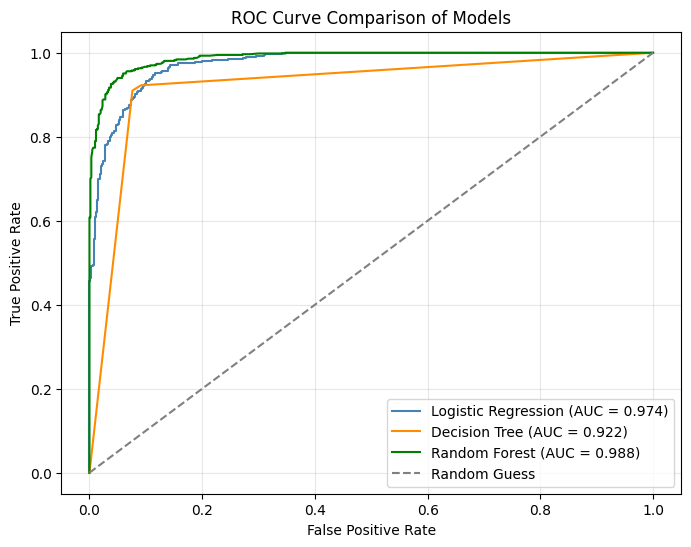

In [56]:
# Comparing ROC Curves of All Models
# This cell plots all three model ROC curves on the same graph so the performance of the models can be compared visually.
# ROC curve points
from sklearn.metrics import roc_curve, roc_auc_score
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr, pos_label=1)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt, pos_label=1)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf, pos_label=1)
# AUC scores
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)
# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})", color="steelblue")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})", color="darkorange")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", color="green")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

                 Model  Accuracy
0  Logistic Regression  0.912821
1        Decision Tree  0.917094
2        Random Forest  0.943590


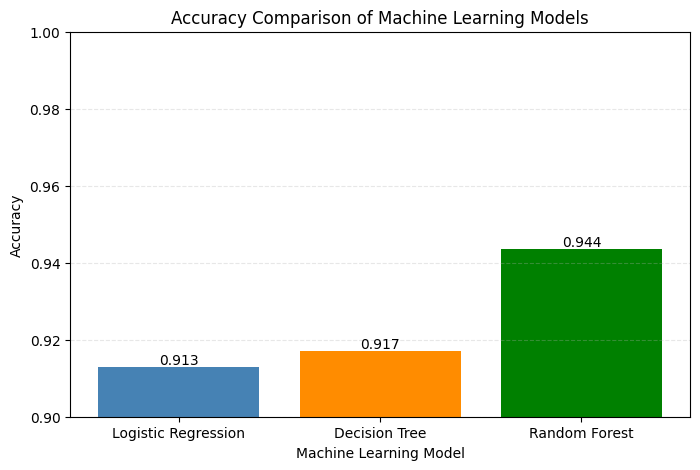

In [57]:
# Comparing performance of all baseline models
model_results = pd.DataFrame({"Model": ["Logistic Regression", "Decision Tree", "Random Forest"],"Accuracy": [logit_accuracy, dt_accuracy, rf_accuracy]})
print(model_results)
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results["Model"],model_results["Accuracy"],color=["steelblue", "darkorange", "green"])
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,height,f"{height:.3f}",ha='center',va='bottom')
plt.title("Accuracy Comparison of Machine Learning Models")
plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Model")
plt.ylim(0.9, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [58]:
# This cell compares the confusion matrices of all three models side by side so we can see exactly where each model made errors.
# Each confusion matrix shows 4 values:
# Top-left     = True Positive  (TP)-phishing correctly detected
# Bottom-right = True Negative  (TN)-legitimate correctly identified
# Top-right    = False Positive (FP)-legitimate wrongly flagged as phishing
# Bottom-left  = False Negative (FN) - phishing wrongly missed
# FN is the most dangerous error in phishing detection


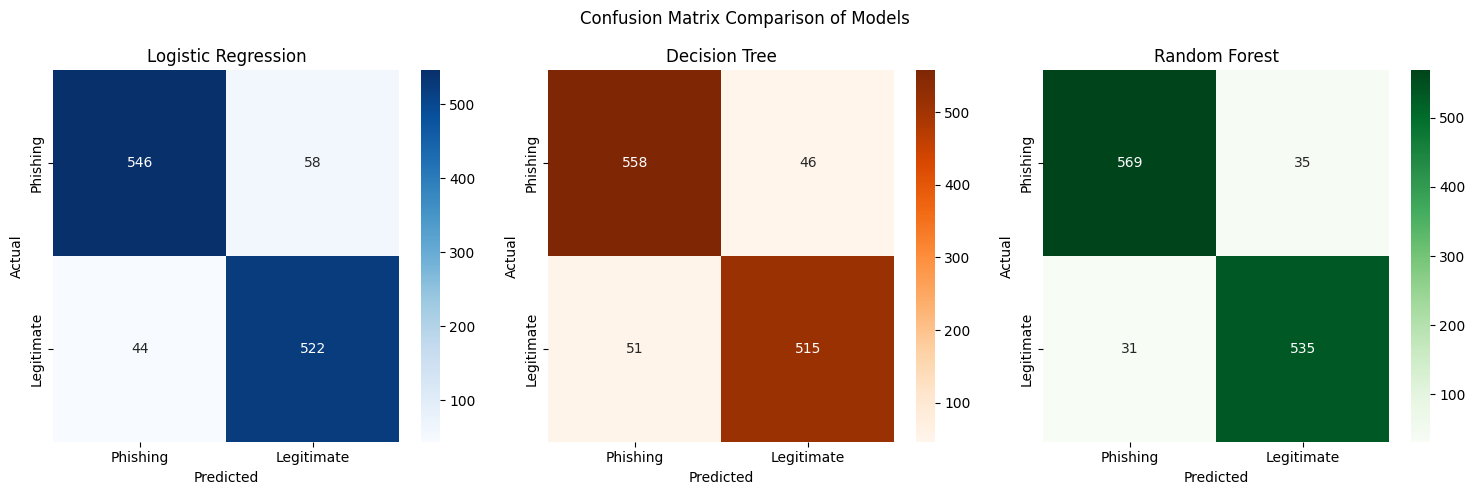

In [59]:
# Confusion Matrix Comparison
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=[-1, 1])
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=[-1, 1])
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[-1, 1])
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.heatmap(cm_lr,annot=True,fmt="d",cmap="Blues",xticklabels=["Phishing", "Legitimate"],yticklabels=["Phishing", "Legitimate"],ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_dt,annot=True,fmt="d",cmap="Oranges",xticklabels=["Phishing", "Legitimate"],yticklabels=["Phishing", "Legitimate"],ax=axes[1])
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(cm_rf,annot=True,fmt="d",cmap="Greens",xticklabels=["Phishing", "Legitimate"],yticklabels=["Phishing", "Legitimate"],ax=axes[2])
axes[2].set_title("Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
plt.suptitle("Confusion Matrix Comparison of Models")
plt.tight_layout()
plt.show()

In [60]:
# Summary table for all models
from sklearn.metrics import f1_score
summary_results = pd.DataFrame({"Model": ["Logistic Regression", "Decision Tree", "Random Forest"],"Accuracy": [logit_accuracy, dt_accuracy, rf_accuracy],"ROC-AUC": [auc_lr, auc_dt, auc_rf],
    "F1-Score": [f1_score(y_test, y_pred_lr, average="weighted"),f1_score(y_test, y_pred_dt, average="weighted"),f1_score(y_test, y_pred_rf, average="weighted")]})
summary_results = summary_results.round(3)
print(summary_results)

                 Model  Accuracy  ROC-AUC  F1-Score
0  Logistic Regression     0.913    0.974     0.913
1        Decision Tree     0.917    0.922     0.917
2        Random Forest     0.944    0.988     0.944


In [61]:
# This bar chart visually compares all three models across
# three metrics at the same time - Accuracy, ROC-AUC and F1-Score.
# plt.ylim(0.85, 1.0) zooms the y-axis to start from 0.85
# instead of 0, which makes the small differences between
# models more visible and easier to compare.

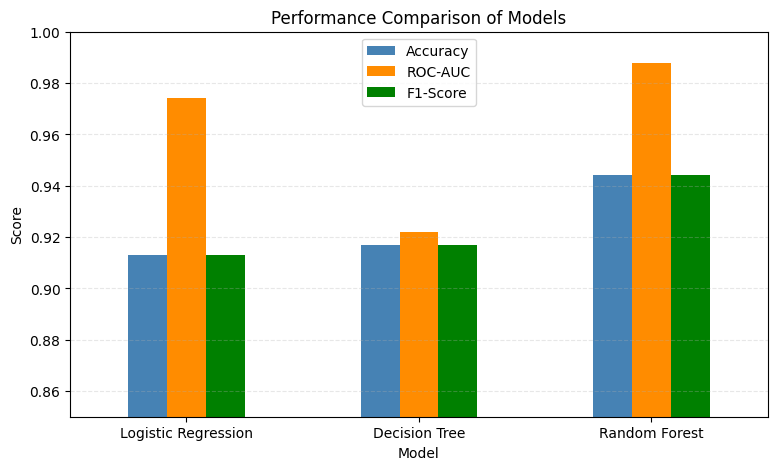

In [62]:
# Bar chart for summary metrics
summary_results.set_index("Model")[["Accuracy", "ROC-AUC", "F1-Score"]].plot( kind="bar",figsize=(9, 5),color=["steelblue", "darkorange", "green"])
plt.title("Performance Comparison of Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0.85, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

# XAI on Random Forest (LIME + SHAP)

In [64]:
!pip install shap

In [65]:
# Install explainability libraries
!pip install shap lime -q
# my system environment kept throwing error thayts why using this code

In [66]:
!pip install shap

In [67]:
import sys
!{sys.executable} -m pip install shap
# system error so using this line of code

In [68]:
import shap

In [69]:
!pip install lime

In [70]:
import sys
!{sys.executable} -m pip install lime
# this line is coded because of error thats why i had to create a new environment 

In [71]:
import lime
import lime.lime_tabular

In [72]:
# Initialising SHAP TreeExplainer
explainer = shap.TreeExplainer(rf_model)
# Calculating SHAP values
shap_values = explainer.shap_values(X_test)
# Select SHAP values for class 1 (Legitimate)
shap_values_class1 = shap_values[1]

In [73]:
# Check the type and shape of SHAP values
print("Type of shap_values:", type(shap_values))
print("Shape of shap_values:", np.array(shap_values).shape)

Type of shap_values: <class 'numpy.ndarray'>
Shape of shap_values: (1170, 30, 2)


In [74]:
# Extract SHAP values for both classes
# Class 0 = phishing (-1)
# Class 1 = legitimate (1)

shap_values_phishing = shap_values[:, :, 0]
shap_values_legitimate = shap_values[:, :, 1]

print("Phishing SHAP shape:", shap_values_phishing.shape)
print("Legitimate SHAP shape:", shap_values_legitimate.shape)

Phishing SHAP shape: (1170, 30)
Legitimate SHAP shape: (1170, 30)


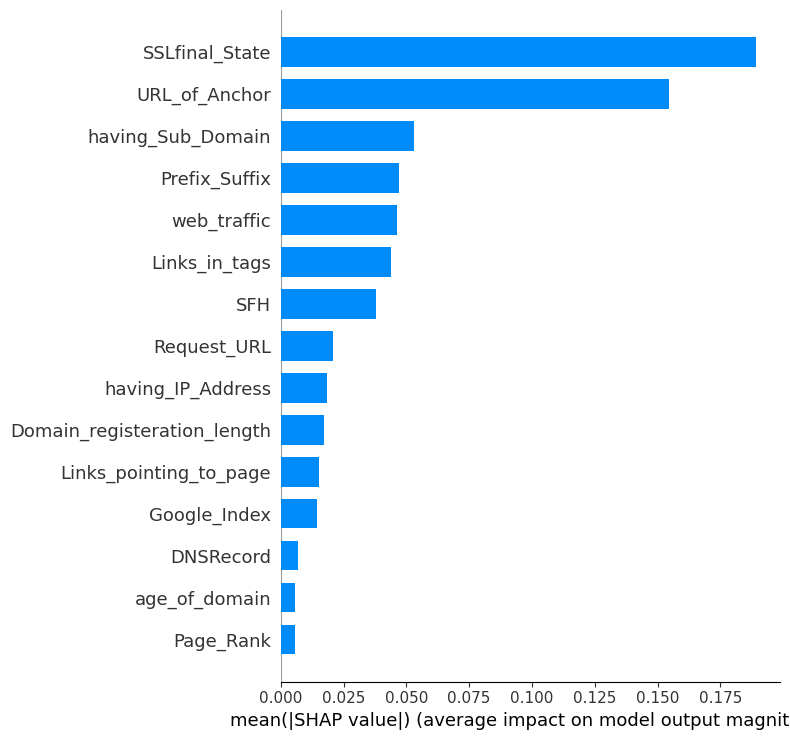

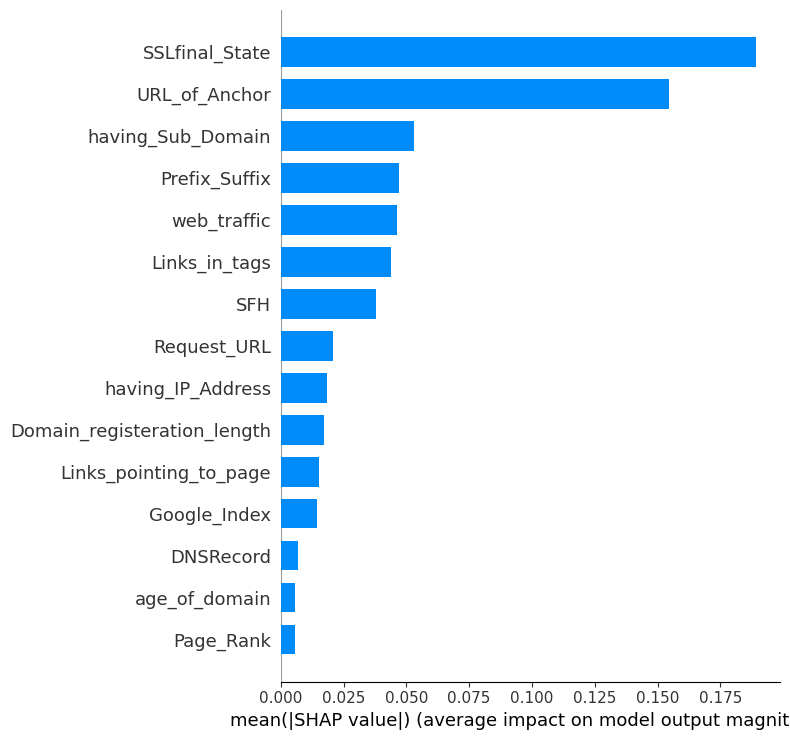

In [75]:
# SHAP feature importance bar plot for phishing predictions
shap.summary_plot(shap_values_phishing, X_test, plot_type="bar", max_display=15)
# Legitimate explanation
shap.summary_plot(shap_values_legitimate, X_test, plot_type="bar", max_display=15)

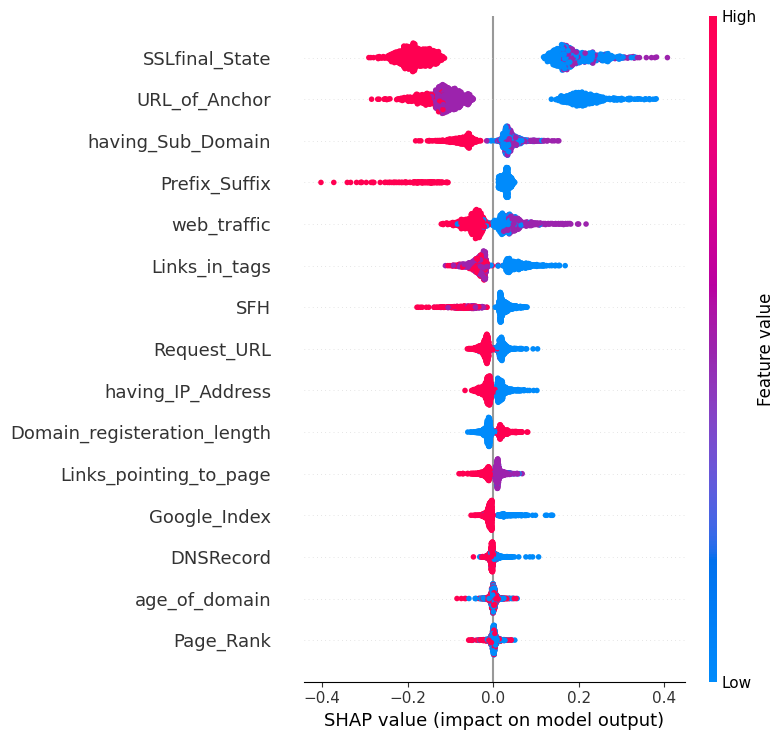

In [76]:
# SHAP summary plot showing feature impact for phishing predictions
# SHAP beeswarm plot - phishing class
shap.summary_plot(shap_values_phishing, X_test, max_display=15)
# This plot shows both the magnitude AND direction of each features effect on the phishing prediction.

In [77]:
print(explainer.expected_value)
print(shap_values.shape)

[0.51633682 0.48366318]
(1170, 30, 2)


Model classes: [-1  1]
Actual label: -1
Predicted label: -1
Predicted probabilities: [[0.99666667 0.00333333]]


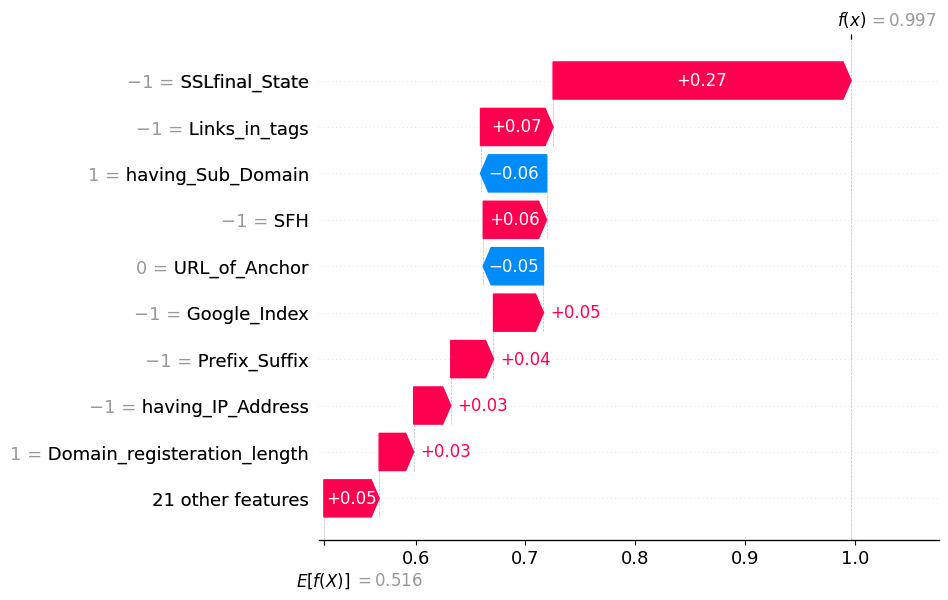

In [78]:
# Check class order first
print("Model classes:", rf_model.classes_)
# Choose one sample
sample_index = 0
# Optional: confirm actual and predicted class
print("Actual label:", y_test.iloc[sample_index])
print("Predicted label:", rf_model.predict(X_test.iloc[[sample_index]])[0])
print("Predicted probabilities:", rf_model.predict_proba(X_test.iloc[[sample_index]]))

# SHAP waterfall plot for phishing class
shap.plots.waterfall(shap.Explanation(values=shap_values_phishing[sample_index],base_values=explainer.expected_value[0],data=X_test.iloc[sample_index],
feature_names=X_test.columns.tolist()))

Actual label: 1
Predicted label: 1
Predicted probabilities: [[0.13333333 0.86666667]]


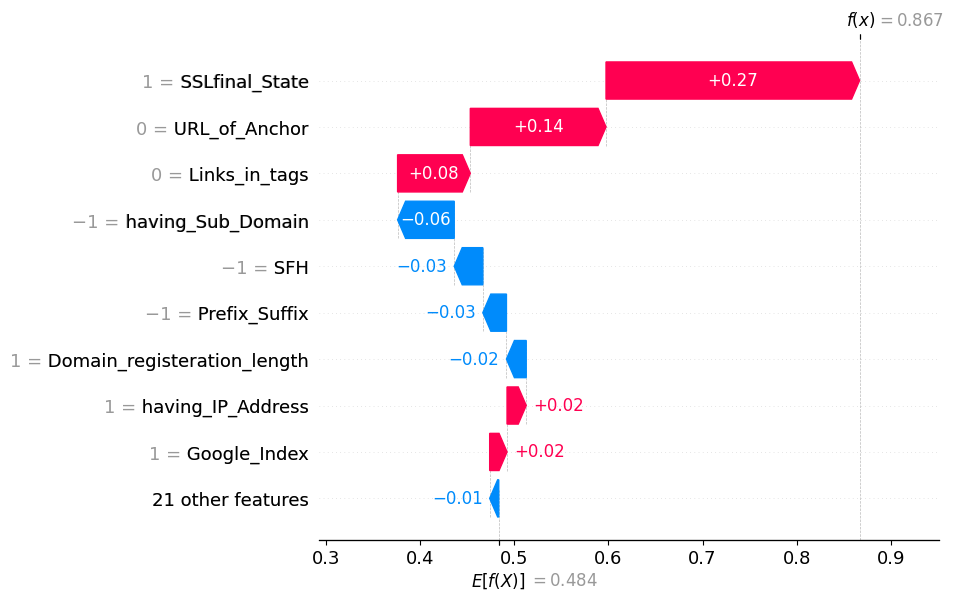

In [79]:
# choose one legitimate sample
import numpy as np

legit_positions = np.where(y_test.values == 1)[0]
sample_index = legit_positions[0]

print("Actual label:", y_test.iloc[sample_index])
print("Predicted label:", rf_model.predict(X_test.iloc[[sample_index]])[0])
print("Predicted probabilities:", rf_model.predict_proba(X_test.iloc[[sample_index]]))
shap.plots.waterfall(shap.Explanation(values=shap_values_legitimate[sample_index], base_values=explainer.expected_value[1], data=X_test.iloc[sample_index], feature_names=X_test.columns.tolist()))

In [80]:
# Import LIME library for local explainability
import lime
import lime.lime_tabular

In [174]:
np.random.seed(42) 

In [176]:
# Create LIME explainer using the training data
lime_explainer = lime.lime_tabular.LimeTabularExplainer(training_data=X_train.values,feature_names=X_train.columns.tolist(),class_names=["Phishing", "Legitimate"],mode="classification")

In [178]:
# Check class order used by the Random Forest model
print("Random Forest classes:", rf_model.classes_)

Random Forest classes: [-1  1]


Actual Label: -1
Predicted Label: -1
Prediction Probabilities: [0.99666667 0.00333333]


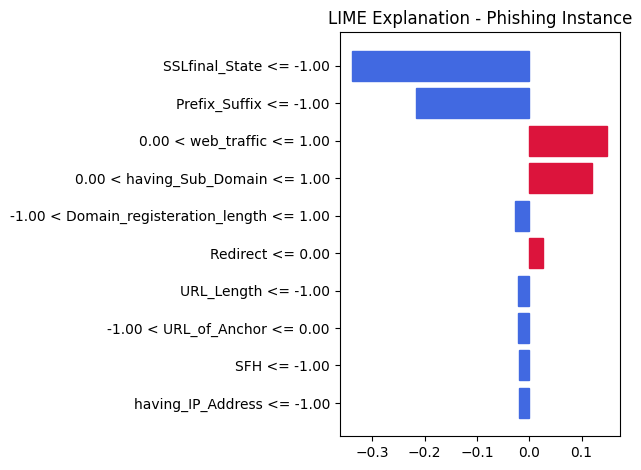

In [180]:
# Generate LIME explanation for one phishing sample
sample_index = 0

actual_label = y_test.iloc[sample_index]
predicted_label = rf_model.predict(X_test.iloc[[sample_index]])[0]
predicted_prob = rf_model.predict_proba(X_test.iloc[[sample_index]])[0]

print("Actual Label:", actual_label)
print("Predicted Label:", predicted_label)
print("Prediction Probabilities:", predicted_prob)

lime_exp = lime_explainer.explain_instance(X_test.iloc[sample_index].values, rf_model.predict_proba, num_features=10)

fig = lime_exp.as_pyplot_figure()

# apply custom colors
for bar in plt.gca().patches:
    if bar.get_width() > 0:
        bar.set_color('crimson')      # phishing
    else:
        bar.set_color('royalblue')   # legitimate

plt.title("LIME Explanation - Phishing Instance")
plt.tight_layout()
plt.savefig("lime_phishing_instance.png", dpi=300, bbox_inches="tight")
plt.show()

Actual Label: 1
Predicted Label: 1
Prediction Probabilities: [0.13333333 0.86666667]


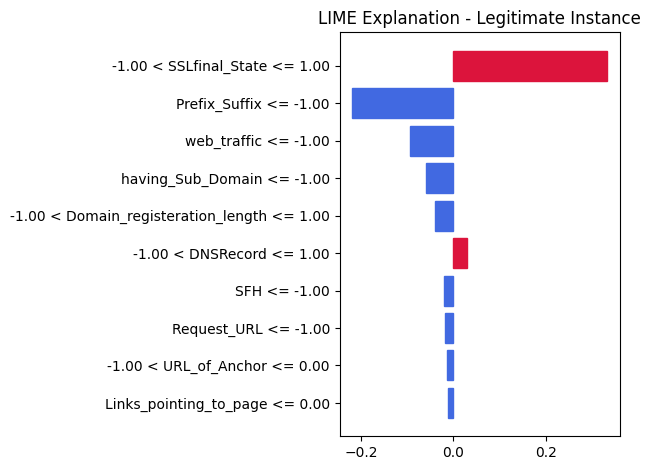

In [182]:
# Generate LIME explanation for one legitimate sample
# This is important because sample_index = 0 was a phishing sample. To get a legitimate sample I need to search for one specifically using np.where.
# I then check the actual label and predicted label to confirm the model correctly predicted this sample as legitimate before generating the LIME explanation.
# Generate LIME explanation for one legitimate sample
legit_positions = np.where(y_test.values == 1)[0]
sample_legit = legit_positions[0]

actual_label_legit = y_test.iloc[sample_legit]
predicted_label_legit = rf_model.predict(X_test.iloc[[sample_legit]])[0]
predicted_prob_legit = rf_model.predict_proba(X_test.iloc[[sample_legit]])[0]

print("Actual Label:", actual_label_legit)
print("Predicted Label:", predicted_label_legit)
print("Prediction Probabilities:", predicted_prob_legit)

lime_exp_legit = lime_explainer.explain_instance(X_test.iloc[sample_legit].values, rf_model.predict_proba, num_features=10)

fig = lime_exp_legit.as_pyplot_figure()

# apply same colors (crimson = supports prediction, royalblue = opposes)
for bar in plt.gca().patches:
    if bar.get_width() > 0:
        bar.set_color('crimson')
    else:
        bar.set_color('royalblue')

plt.title("LIME Explanation - Legitimate Instance")
plt.tight_layout()
plt.savefig("lime_legitimate_instance.png", dpi=300, bbox_inches="tight")
plt.show()

In [184]:
print("LIME Explanation for Phishing Sample:")
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")

print("\nLIME Explanation for Legitimate Sample:")
for feature, weight in lime_exp_legit.as_list():
    print(f"{feature}: {weight:.4f}")

LIME Explanation for Phishing Sample:
SSLfinal_State <= -1.00: -0.3385
Prefix_Suffix <= -1.00: -0.2163
0.00 < web_traffic <= 1.00: 0.1492
0.00 < having_Sub_Domain <= 1.00: 0.1207
-1.00 < Domain_registeration_length <= 1.00: -0.0273
Redirect <= 0.00: 0.0266
URL_Length <= -1.00: -0.0223
-1.00 < URL_of_Anchor <= 0.00: -0.0209
SFH <= -1.00: -0.0197
having_IP_Address <= -1.00: -0.0196

LIME Explanation for Legitimate Sample:
-1.00 < SSLfinal_State <= 1.00: 0.3332
Prefix_Suffix <= -1.00: -0.2192
web_traffic <= -1.00: -0.0943
having_Sub_Domain <= -1.00: -0.0589
-1.00 < Domain_registeration_length <= 1.00: -0.0404
-1.00 < DNSRecord <= 1.00: 0.0300
SFH <= -1.00: -0.0201
Request_URL <= -1.00: -0.0194
-1.00 < URL_of_Anchor <= 0.00: -0.0139
Links_pointing_to_page <= 0.00: -0.0123


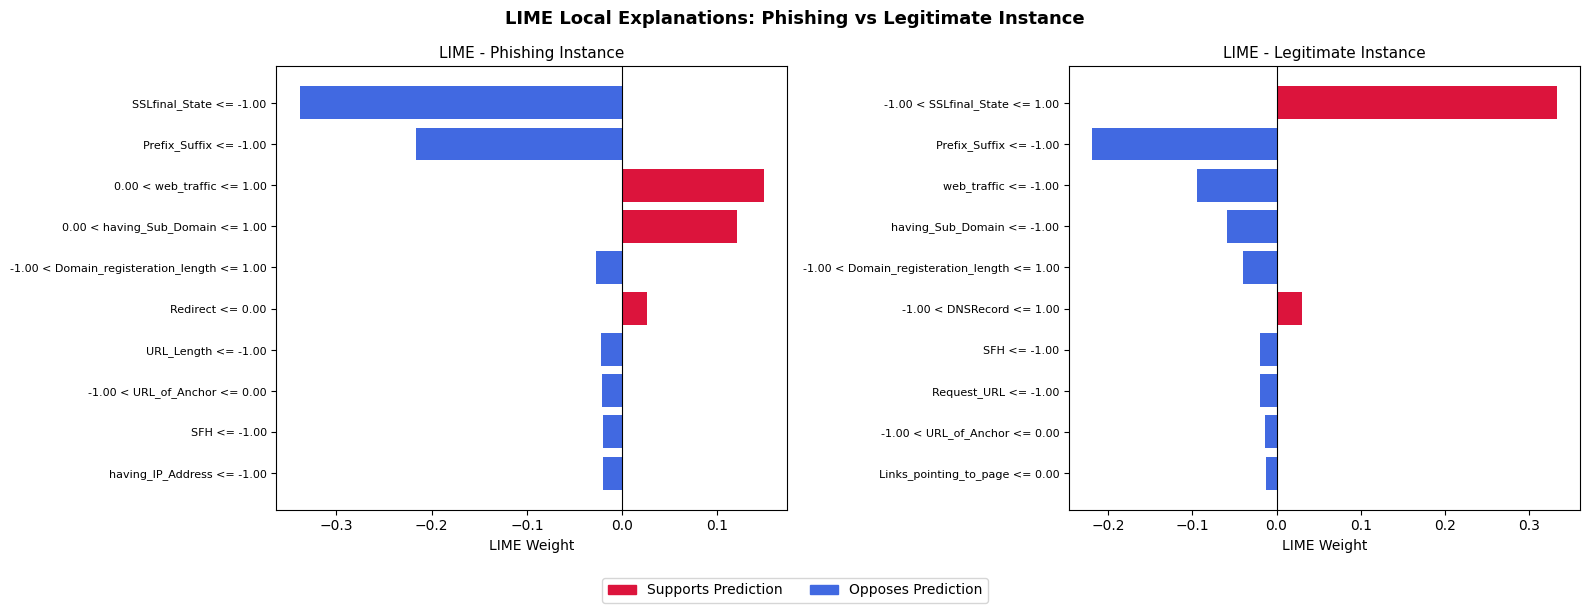

Saved: lime_comparison_phishing_vs_legitimate.png


In [186]:
import matplotlib.patches as mpatches

# This cell creates a side-by-side bar chart to compare LIME explanations

def get_lime_weights(exp, top_n=10):
    return [(item[0], item[1]) for item in exp.as_list()[:top_n]]

phish_weights = get_lime_weights(lime_exp, top_n=10)
legit_weights = get_lime_weights(lime_exp_legit, top_n=10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Phishing panel
feats_p = [w[0] for w in phish_weights]
vals_p  = [w[1] for w in phish_weights]
colors_p = ["crimson" if v > 0 else "royalblue" for v in vals_p]

axes[0].barh(range(len(feats_p)), vals_p, color=colors_p)
axes[0].set_yticks(range(len(feats_p)))
axes[0].set_yticklabels(feats_p, fontsize=8)
axes[0].set_xlabel("LIME Weight")
axes[0].set_title("LIME - Phishing Instance", fontsize=11)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].invert_yaxis()

# Legitimate panel
feats_l = [w[0] for w in legit_weights]
vals_l  = [w[1] for w in legit_weights]
colors_l = ["crimson" if v > 0 else "royalblue" for v in vals_l]

axes[1].barh(range(len(feats_l)), vals_l, color=colors_l)
axes[1].set_yticks(range(len(feats_l)))
axes[1].set_yticklabels(feats_l, fontsize=8)
axes[1].set_xlabel("LIME Weight")
axes[1].set_title("LIME - Legitimate Instance", fontsize=11)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].invert_yaxis()

# Legend
red_patch  = mpatches.Patch(color="crimson", label="Supports Prediction")
blue_patch = mpatches.Patch(color="royalblue", label="Opposes Prediction")

fig.legend(handles=[red_patch, blue_patch], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle("LIME Local Explanations: Phishing vs Legitimate Instance",
             fontsize=13, fontweight="bold")

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("lime_comparison_phishing_vs_legitimate.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: lime_comparison_phishing_vs_legitimate.png")

# This cell compares the top 10 most important features identified by SHAP and LIME for the same phishing instance to check how consistent the two XAI methods are with each other.

In [188]:
# Top 10 SHAP features for phishing instance
mean_abs_shap = np.abs(shap_values_phishing[sample_index])
shap_top10_idx = np.argsort(mean_abs_shap)[::-1][:10]
shap_top10 = list(X_test.columns[shap_top10_idx])

# Top 10 LIME features for phishing instance
lime_top10_raw = [item[0] for item in lime_exp.as_list()[:10]]
lime_top10 = []
for raw in lime_top10_raw:
    matched = None
    # Sort columns by length (longest first) to avoid partial matches
    for col in sorted(X_test.columns, key=len, reverse=True):
        if col in raw:
            matched = col
            break
    if matched and matched not in lime_top10:
        lime_top10.append(matched)

# Agreement
overlap = set(shap_top10) & set(lime_top10)
agreement_pct = len(overlap) / 10 * 100
print("SHAP vs LIME Agreement — Phishing Instance")
print(f"SHAP top 10 : {shap_top10}")
print(f"LIME top 10 : {lime_top10}")
print(f"Shared      : {sorted(overlap)}")
print(f"Agreement   : {len(overlap)}/10 ({agreement_pct:.0f}%)")



SHAP vs LIME Agreement — Phishing Instance
SHAP top 10 : ['SSLfinal_State', 'Links_in_tags', 'having_Sub_Domain', 'SFH', 'URL_of_Anchor', 'Google_Index', 'Prefix_Suffix', 'having_IP_Address', 'Domain_registeration_length', 'Links_pointing_to_page']
LIME top 10 : ['SSLfinal_State', 'Prefix_Suffix', 'web_traffic', 'having_Sub_Domain', 'Domain_registeration_length', 'Redirect', 'URL_Length', 'URL_of_Anchor', 'SFH', 'having_IP_Address']
Shared      : ['Domain_registeration_length', 'Prefix_Suffix', 'SFH', 'SSLfinal_State', 'URL_of_Anchor', 'having_IP_Address', 'having_Sub_Domain']
Agreement   : 7/10 (70%)


In [190]:
# Debug: verify variables before plotting
print("SHAP top 10:", shap_top10)
print("LIME top 10:", lime_top10)
print("Overlap:", sorted(overlap))
print("Agreement:", len(overlap), "/10")

SHAP top 10: ['SSLfinal_State', 'Links_in_tags', 'having_Sub_Domain', 'SFH', 'URL_of_Anchor', 'Google_Index', 'Prefix_Suffix', 'having_IP_Address', 'Domain_registeration_length', 'Links_pointing_to_page']
LIME top 10: ['SSLfinal_State', 'Prefix_Suffix', 'web_traffic', 'having_Sub_Domain', 'Domain_registeration_length', 'Redirect', 'URL_Length', 'URL_of_Anchor', 'SFH', 'having_IP_Address']
Overlap: ['Domain_registeration_length', 'Prefix_Suffix', 'SFH', 'SSLfinal_State', 'URL_of_Anchor', 'having_IP_Address', 'having_Sub_Domain']
Agreement: 7 /10


In [194]:
print("SHAP top 10:", shap_top10)
print("LIME top 10:", lime_top10)
print("Shared:", sorted(overlap))
print("Agreement:", len(overlap), "/10")

SHAP top 10: ['SSLfinal_State', 'Links_in_tags', 'having_Sub_Domain', 'SFH', 'URL_of_Anchor', 'Google_Index', 'Prefix_Suffix', 'having_IP_Address', 'Domain_registeration_length', 'Links_pointing_to_page']
LIME top 10: ['SSLfinal_State', 'Prefix_Suffix', 'web_traffic', 'having_Sub_Domain', 'Domain_registeration_length', 'Redirect', 'URL_Length', 'URL_of_Anchor', 'SFH', 'having_IP_Address']
Shared: ['Domain_registeration_length', 'Prefix_Suffix', 'SFH', 'SSLfinal_State', 'URL_of_Anchor', 'having_IP_Address', 'having_Sub_Domain']
Agreement: 7 /10


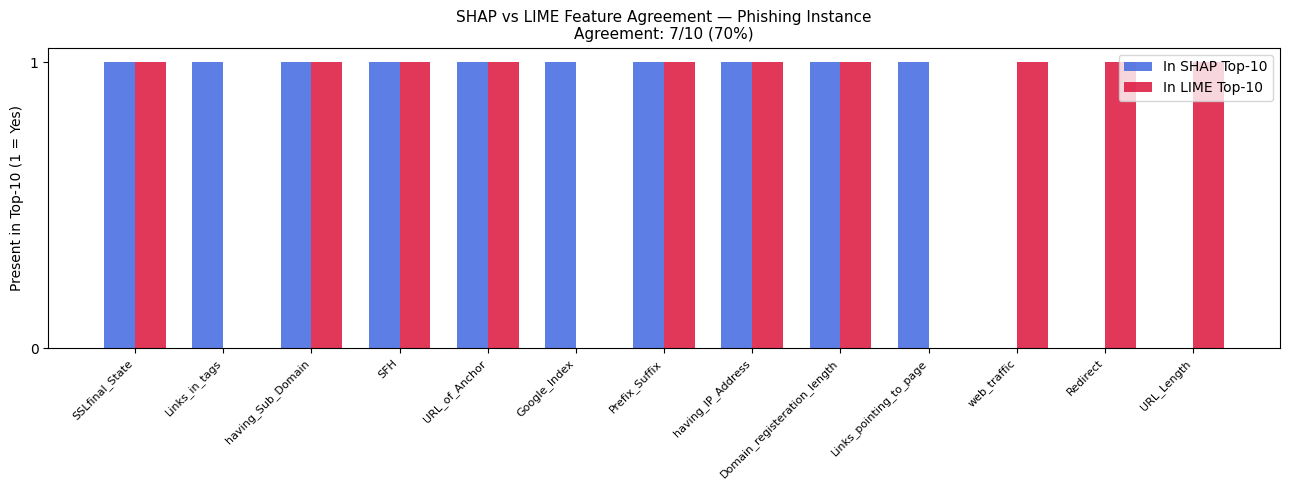

Features with BOTH bars (shared):
 - SSLfinal_State
 - having_Sub_Domain
 - SFH
 - URL_of_Anchor
 - Prefix_Suffix
 - having_IP_Address
 - Domain_registeration_length


In [196]:
# All unique features from both lists
all_feats = list(dict.fromkeys(shap_top10 + lime_top10))

# Checking presence in each list
in_shap = [1 if f in shap_top10 else 0 for f in all_feats]
in_lime = [1 if f in lime_top10 else 0 for f in all_feats]

# BarPlot
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(all_feats))
w = 0.35
ax.bar(x - w/2, in_shap, w, label="In SHAP Top-10", color="royalblue", alpha=0.85)
ax.bar(x + w/2, in_lime, w, label="In LIME Top-10", color="crimson", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(all_feats, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Present in Top-10 (1 = Yes)")
ax.set_yticks([0, 1])
ax.set_title(f"SHAP vs LIME Feature Agreement — Phishing Instance\nAgreement: {len(overlap)}/10 ({agreement_pct:.0f}%)", fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig("shap_lime_agreement_fixed.png", dpi=300, bbox_inches="tight")
plt.show()
print("Features with BOTH bars (shared):")
for i, f in enumerate(all_feats):
    if in_shap[i] == 1 and in_lime[i] == 1:
        print(f" - {f}")